# Setup  

In [ ]:
!apt-get install r-base

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.3-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
!pip install "rpy2[all]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.2 MB/s eta 0:00:00


In [ ]:
import rpy2
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

In [ ]:
%load_ext rpy2.ipython

In [ ]:
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector

utils = rpackages.importr("utils")
utils.chooseCRANmirror(ind=1)

packages = ["lcmm"]
# packages = ["lcmm", "moments"]
utils.install_packages(StrVector(packages))

(as ‘lib’ is unspecified)












	‘/tmp/Rtmpp9IkyU/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x7d1f90d1dfd0> [0]

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
%%R
R.version.string

[1] "R version 4.5.3 (2026-03-11)"


In [ ]:
!python --version

Python 3.12.13


In [ ]:
drive.mount('/content/drive')

df_curated = pd.read_excel("/content/drive/MyDrive/data/PPMI_Curated_Data_Cut_Public_20260223.xlsx")

df_vital = pd.read_csv("/content/drive/MyDrive/data/Vital_Signs_21Mar2026.csv")

Mounted at /content/drive


# Inclusion criteria   


In [ ]:
curated = df_curated[[
    # ID
    "PATNO",
    "COHORT",
    "EVENT_ID",

    # time variable
    "YEAR", # visit year, derived from EVENT_ID, numeric
    "visit_date", # Month and Year of Clinical Visit (Note: Collection dates of DATSCAN, lumbar puncture, or other imaging/lab data may be different.)

    # sleep
    "rem", # REM Sleep Behavior Disorder Screening Questionnaire (RBDSQ) total score
    # autonomic dysfunction
    "scopa", # SCOPA-AUT Total Score
    # psychiatric
    "stai", #State-Trait Anxiety Index (STAI) Total Score
    # cognitive
    "DVT_SDM", # Symbol Digit Modalities Test t-score (age- and education-corrected), DVT_SDM = 10*SD + 50, where SD is derived as above
    # motor
    "updrs3_score", # Score is based on values taken when participant is either "OFF" PD medication or untreated for PD

    # demo & clinical
    "SEX",
    "EDUCYRS", #Years of Education capped at 20
    "age", # age at enrollment
    "fampd_bin",  # Family History of PD - Binary, 1 Any Family w/PD, 2 No Family w/PD
    "LEDD", # Total Levodopa Equivalent Daily Dose
    "duration_yrs", # Duration from PD Diagnosis to Enrollment (Years)
    "hy", # Reclassified Hoehn & Yahr Stage (includes OFF and untreated scores)
    "ageonset",
    "subgroup",
    "moca",
    "gds",
    "stai_state",
    "stai_trait",
    "pigd",
    "COG_COMPOSITE_INT",
    "COG_COMPOSITE_EXT",
    "td_pigd",
    "ess",
    "MSEADLG",
    "upsit_pctl15",
    "cogstate"
]].copy()

In [ ]:
vs = df_vital[[
    "PATNO",
    "EVENT_ID",
    "SYSSUP",   # Supine BP - systolic (mmHg)
    "SYSSTND"    # Standing BP - systolic (mmHg)
]].copy()

In [ ]:
df = curated.merge(
    vs,
    on=["PATNO", "EVENT_ID"],
    how="left",
    validate="one_to_one"
)

In [ ]:
df["delta_sbp"] = df["SYSSUP"] - df["SYSSTND"]
df["delta_sbp"].describe()

,delta_sbp
count,17203.000000
mean,4.076731
std,13.370832
min,-77.000000
25%,-4.000000
50%,3.000000
75%,11.000000
max,111.000000


(-50.0, 100.0)

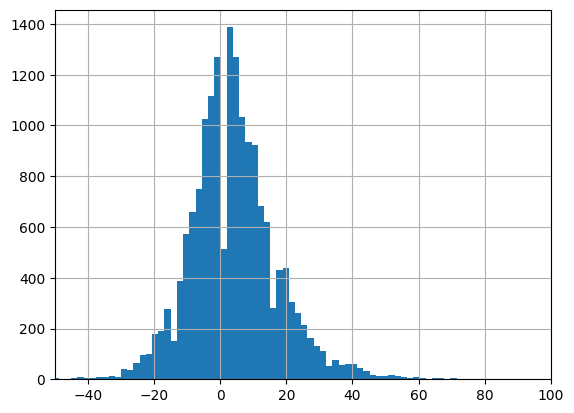

In [ ]:
df["delta_sbp"].hist(bins=100)
plt.xlim(-50, 100)

In [ ]:
df_pd = df[df["COHORT"] == 1].copy()

In [ ]:
bl_pd = df_pd[df_pd["YEAR"] == 0].copy()

In [ ]:
# boolean series
mask = (
    (bl_pd["ageonset"] >= 50) &
    (bl_pd["duration_yrs"] <=2) &
    (bl_pd["LEDD"] == 0) &
    (bl_pd["hy"] != 3) &
    (bl_pd["cogstate"] != 3)
)

ids = bl_pd.loc[mask, "PATNO"].dropna().unique()
print(len(ids))

919


In [ ]:
df_pd = df_pd[df_pd["PATNO"].isin(ids)].copy()

In [ ]:
visit_counts = df_pd.groupby("PATNO")["YEAR"].nunique()
ids_2plus = visit_counts[visit_counts >=2].index
df_pd_final = df_pd[df_pd["PATNO"].isin(ids_2plus)].copy()

In [ ]:
print(f"Unique subjects: {df_pd_final['PATNO'].nunique()}")
print(f"Total rows: {len(df_pd_final)}")

print("YEAR range:", df_pd_final["YEAR"].min(), df_pd_final["YEAR"].max())

print(df_pd_final.groupby("PATNO")["YEAR"].nunique().describe())

print(df_pd_final.groupby("YEAR")["PATNO"].nunique())

Unique subjects: 855
Total rows: 4542
YEAR range: 0 15
count    855.000000
mean       5.312281
std        3.653560
min        2.000000
25%        3.000000
50%        4.000000
75%        7.000000
max       15.000000
Name: YEAR, dtype: float64
YEAR
0     855
1     828
2     671
3     481
4     330
5     244
6     209
7     184
8     130
9     122
10    136
11    128
12    120
13     79
14     23
15      2
Name: PATNO, dtype: int64


In [ ]:
df_pd_final = df_pd_final[df_pd_final["YEAR"] <= 5].copy()

In [ ]:
print(f"Unique subjects: {df_pd_final['PATNO'].nunique()}")
print(f"Total rows: {len(df_pd_final)}")

print("YEAR range:", df_pd_final["YEAR"].min(), df_pd_final["YEAR"].max())

print(df_pd_final.groupby("PATNO")["YEAR"].nunique().describe())

print(df_pd_final.groupby("YEAR")["PATNO"].nunique())

Unique subjects: 855
Total rows: 3409
YEAR range: 0 5
count    855.000000
mean       3.987135
std        1.491921
min        2.000000
25%        3.000000
50%        4.000000
75%        6.000000
max        6.000000
Name: YEAR, dtype: float64
YEAR
0    855
1    828
2    671
3    481
4    330
5    244
Name: PATNO, dtype: int64


In [ ]:
vars_model = [
    "rem", "moca", "updrs3_score", "delta_sbp", "gds", "pigd"]

missing_model = df_pd_final[vars_model].isna().mean().sort_values(ascending=False)

print(missing_model)

updrs3_score    0.159871
pigd            0.157524
delta_sbp       0.029921
moca            0.010854
rem             0.008800
gds             0.008800
dtype: float64


In [ ]:
vars_model = ["rem", "moca", "updrs3_score", "delta_sbp", "gds", "pigd"]

vars_model = [c for c in vars_model if c in df_pd_final.columns]

scale_yr_sub_df = (
    df_pd_final[["PATNO", "YEAR"] + vars_model]
    .dropna(subset=vars_model, how="all")
    .groupby("YEAR")[["PATNO"] + vars_model]
    .apply(lambda x: x.groupby("PATNO")[vars_model].apply(lambda y: y.notna().any()).sum())
)

display(scale_yr_sub_df)

,rem,moca,updrs3_score,delta_sbp,gds,pigd
YEAR,,,,,,
0,851,853,850,849,852,852
1,821,821,698,792,822,701
2,666,664,529,643,664,532
3,477,474,354,465,478,355
4,323,320,250,317,321,249
5,241,240,183,241,242,183


In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

# MCAR

In [ ]:
packages = ["MissMech", "naniar"]
utils.install_packages(StrVector(packages))

(as ‘lib’ is unspecified)












	‘/tmp/RtmpFBXNwH/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x7cd5f790d7d0> [0]

In [ ]:
%%R -i df
library(naniar)

dat <- as.data.frame(df)

vars_mcar <- c("rem", "moca", "updrs3_score", "delta_sbp")
dat_mcar <- dat[, vars_mcar]

mcar_test(dat_mcar)

# A tibble: 1 × 4
  statistic    df p.value missing.patterns
      <dbl> <dbl>   <dbl>            <int>
1      208.    28       0               16


# missing pattern

In [ ]:
packages = ["VIM"]
utils.install_packages(StrVector(packages))

(as ‘lib’ is unspecified)





























































	‘/tmp/RtmpFBXNwH/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x7cd5f790d7d0> [0]


 Variables sorted by number of missings: 
     Variable       Count
 updrs3_score 0.159870930
    delta_sbp 0.029920798
         moca 0.010853623
          rem 0.008800235


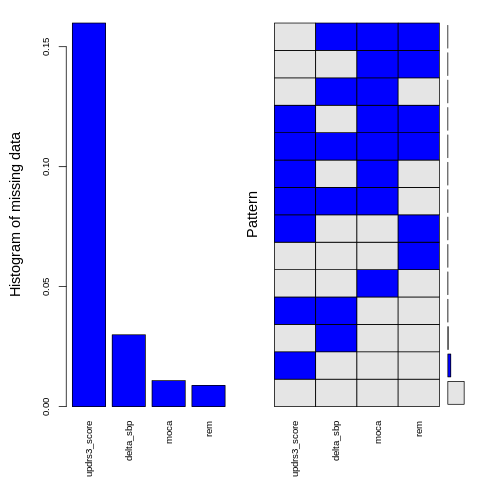

In [ ]:
%%R
library(VIM)

vars <- df[, c(
  "rem", "moca", "updrs3_score", "delta_sbp"
)]

aggr(
  vars,
  col = c("grey90", "blue"),
  numbers = FALSE,
  sortVars = TRUE,
  labels = names(vars),
  cex.axis = 0.8,
  gap = 3,
  ylab = c("Histogram of missing data", "Pattern")
)

# multlcmm, random=~1, zscore(moca_transform), linear

## visualization

In [42]:
%%R

m_final <- readRDS("/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear.rds")

class(m_final)
VarExpl(m_final)

                           class1     class2     class3
%Var-z_bl_rem          39.1378383 39.1378383 39.1378383
%Var-z_bl_trans_moca    0.4972484  0.4972484  0.4972484
%Var-z_bl_updrs3_score  0.2041472  0.2041472  0.2041472
%Var-z_bl_delta_sbp     0.7413083  0.7413083  0.7413083


In [ ]:
df_pd_final["trans_moca"] = np.sqrt(31 - df_pd_final["moca"])

In [ ]:
vars_to_z = ["rem", "trans_moca", "updrs3_score", "delta_sbp"]

base = df_pd_final[df_pd_final["YEAR"] == 0]

mu_base = base[vars_to_z].mean()
sd_base = base[vars_to_z].std()

df_pd_final[["z_bl_" + v for v in vars_to_z]] = (df_pd_final[vars_to_z] - mu_base) / sd_base

In [ ]:
df_pd_final.filter(like="z_bl_").describe()

,z_bl_rem,z_bl_trans_moca,z_bl_updrs3_score,z_bl_delta_sbp
count,3379.000000,3372.000000,2864.000000,3307.000000
mean,0.103496,0.055209,0.411544,0.057693
std,1.050013,1.141820,1.186819,1.073331
min,-1.390360,-1.688101,-2.077751,-4.249612
25%,-0.712310,-0.982341,-0.442863,-0.566941
50%,-0.034261,0.015755,0.272401,-0.018458
75%,0.982813,0.781621,1.192026,0.608380
max,3.016961,5.783589,4.666165,8.365496


In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

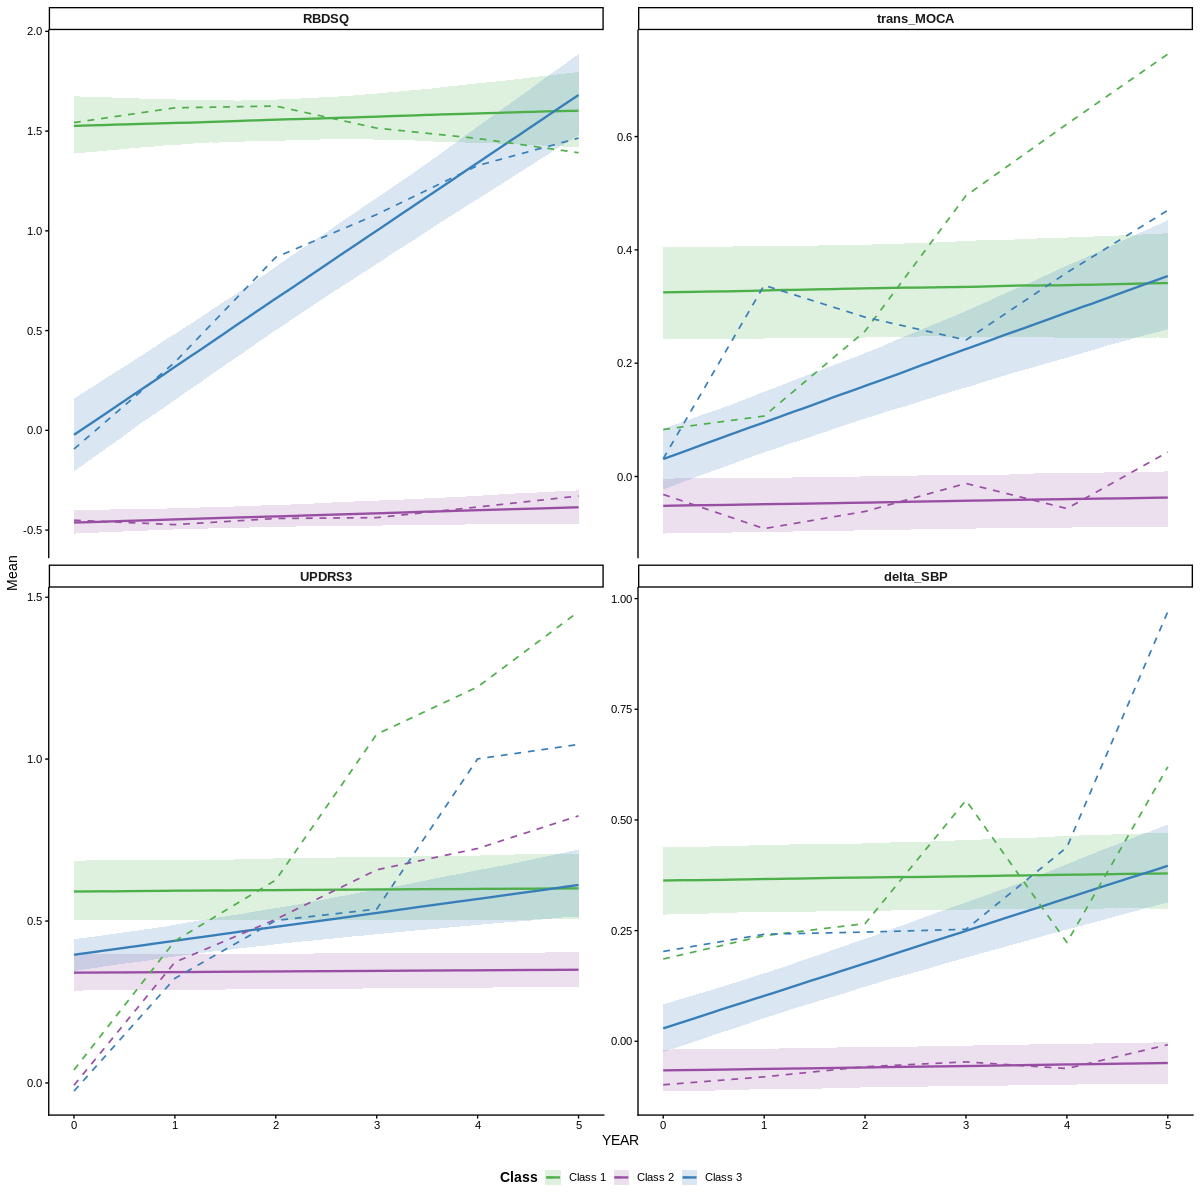

In [ ]:
%%R -w 1200 -h 1200

library(lcmm)
library(readr)
library(dplyr)
library(tidyr)
library(ggplot2)

m_final <- readRDS("/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear.rds")

pp <- read_csv("/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear_postprob.csv", show_col_types = FALSE) %>%
  transmute(
    PATNO = as.numeric(PATNO),
    class = as.integer(class)
  )


df_use <- df %>%
  transmute(
    PATNO = as.numeric(PATNO),
    YEAR,
    z_bl_rem,
    z_bl_trans_moca,
    z_bl_updrs3_score,
    z_bl_delta_sbp
  )

newdata <- data.frame(
  YEAR = seq(
    min(df_use$YEAR, na.rm = TRUE),
    max(df_use$YEAR, na.rm = TRUE),
    length.out = 100
  )
)

pred <- predictY(
  m_final,
  newdata = newdata,
  var.time = "YEAR",
  draws = TRUE
)

pred_df <- as.data.frame(pred$pred)

pred_df <- pred_df %>%
  group_by(Yname) %>%
  mutate(YEAR = newdata$YEAR) %>%
  ungroup() %>%
  mutate(
    Domain = recode(
      Yname,
      z_bl_rem = "RBDSQ",
      z_bl_trans_moca = "trans_MOCA",
      z_bl_updrs3_score = "UPDRS3",
      z_bl_delta_sbp = "delta_SBP"
    )
  )


pred_long <- bind_rows(
  pred_df %>%
    transmute(
      YEAR,
      Domain,
      Class = "Class 1",
      EstimatedMean = Ypred_50_class1,
      Lower = Ypred_2.5_class1,
      Upper = Ypred_97.5_class1
    ),
  pred_df %>%
    transmute(
      YEAR,
      Domain,
      Class = "Class 2",
      EstimatedMean = Ypred_50_class2,
      Lower = Ypred_2.5_class2,
      Upper = Ypred_97.5_class2
    ),
  pred_df %>%
    transmute(
      YEAR,
      Domain,
      Class = "Class 3",
      EstimatedMean = Ypred_50_class3,
      Lower = Ypred_2.5_class3,
      Upper = Ypred_97.5_class3
    )
) %>%
  mutate(
    Domain = factor(Domain, levels = c("RBDSQ", "trans_MOCA", "UPDRS3", "delta_SBP")),
    Class = factor(Class, levels = c("Class 1", "Class 2", "Class 3"))
  )


obs_long <- df_use %>%
  left_join(pp, by = "PATNO") %>%
  filter(!is.na(class)) %>%
  pivot_longer(
    cols = c(z_bl_rem, z_bl_trans_moca, z_bl_updrs3_score, z_bl_delta_sbp),
    names_to = "Yname",
    values_to = "ObservedValue"
  ) %>%
  mutate(
    Domain = recode(
      Yname,
      z_bl_rem = "RBDSQ",
      z_bl_trans_moca = "trans_MOCA",
      z_bl_updrs3_score = "UPDRS3",
      z_bl_delta_sbp = "delta_SBP"
    ),
    Class = paste0("Class ", class)
  ) %>%
  group_by(YEAR, Domain, Class) %>%
  summarise(
    ObservedMean = mean(ObservedValue, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    Domain = factor(Domain, levels = c("RBDSQ", "trans_MOCA", "UPDRS3", "delta_SBP")),
    Class = factor(Class, levels = c("Class 1", "Class 2", "Class 3"))
  )


cols <- c(
  "Class 1" = "#4DAF4A",
  "Class 2" = "#984EA3",
  "Class 3" = "#377EB8"
)


ggplot() +
  # 95% CI
  geom_ribbon(
    data = pred_long,
    aes(
      x = YEAR,
      ymin = Lower,
      ymax = Upper,
      fill = Class,
      group = Class
    ),
    alpha = 0.18,
    color = NA
  ) +
  # estimated mean trajectories
  geom_line(
    data = pred_long,
    aes(
      x = YEAR,
      y = EstimatedMean,
      color = Class,
      group = Class
    ),
    linewidth = 1.1
  ) +
  # observed mean trajectories
  geom_line(
    data = obs_long,
    aes(
      x = YEAR,
      y = ObservedMean,
      color = Class,
      group = Class
    ),
    linetype = "dashed",
    linewidth = 0.8
  ) +
  facet_wrap(~Domain, nrow = 2, ncol = 2, scales = "free_y") +
  scale_color_manual(values = cols) +
  scale_fill_manual(values = cols) +
  labs(
    x = "YEAR",
    y = "Mean",
    color = "Class",
    fill = "Class"
  ) +
  theme_classic(base_size = 14) +
  theme(
    strip.text = element_text(face = "bold", size = 13),
    legend.position = "bottom",
    legend.title = element_text(face = "bold")
  )

In [ ]:
%%R
names(pred_df)


 [1] "Yname"             "Ypred_50_class1"   "Ypred_50_class2"  
 [4] "Ypred_50_class3"   "Ypred_2.5_class1"  "Ypred_2.5_class2" 
 [7] "Ypred_2.5_class3"  "Ypred_97.5_class1" "Ypred_97.5_class2"
[10] "Ypred_97.5_class3" "YEAR"              "Domain"           


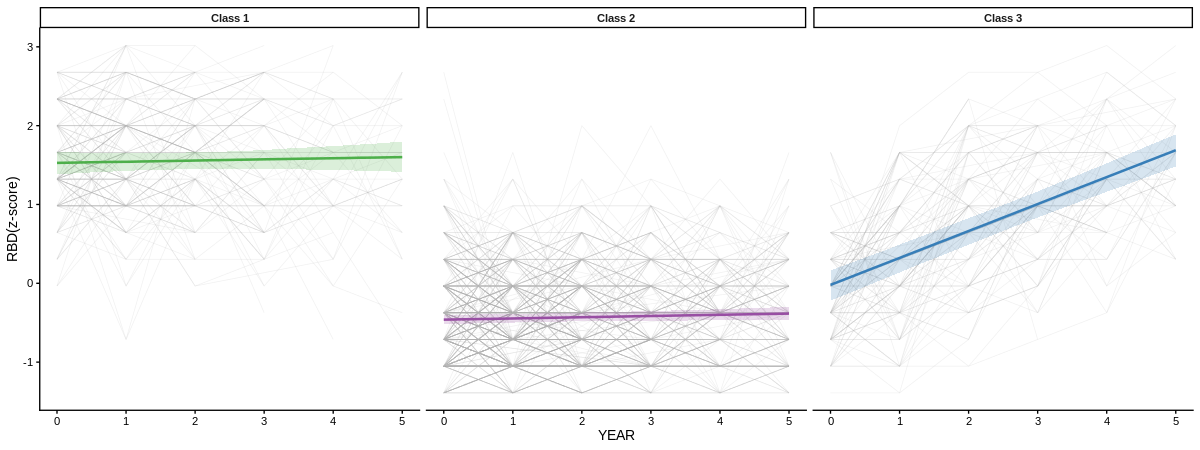

In [ ]:
%%R -w 1200 -h 450

library(lcmm)
library(readr)
library(dplyr)
library(ggplot2)

m_final <- readRDS("/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear.rds")

pp <- read_csv("/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear_postprob.csv", show_col_types = FALSE) %>%
  transmute(
    PATNO = as.numeric(PATNO),
    class = as.integer(class)
  )


rbd <- df %>%
  transmute(
    PATNO = as.numeric(PATNO),
    YEAR,
    z_bl_rem
  ) %>%
  left_join(pp, by = "PATNO") %>%
  filter(!is.na(class), !is.na(z_bl_rem), !is.na(YEAR)) %>%
  mutate(
    Class = factor(
      paste0("Class ", class),
      levels = c("Class 1", "Class 2", "Class 3")
    )
  )


newdata <- data.frame(
  YEAR = seq(
    min(rbd$YEAR, na.rm = TRUE),
    max(rbd$YEAR, na.rm = TRUE),
    length.out = 100
  )
)

pred <- predictY(
  m_final,
  newdata = newdata,
  var.time = "YEAR",
  draws = TRUE
)

pred_df <- as.data.frame(pred$pred)


pred_rbd <- pred_df %>%
  filter(Yname == "z_bl_rem") %>%
  mutate(YEAR = newdata$YEAR)

pred_rbd_long <- bind_rows(
  pred_rbd %>%
    transmute(
      YEAR,
      Class = "Class 1",
      EstimatedMean = Ypred_50_class1,
      Lower = Ypred_2.5_class1,
      Upper = Ypred_97.5_class1
    ),
  pred_rbd %>%
    transmute(
      YEAR,
      Class = "Class 2",
      EstimatedMean = Ypred_50_class2,
      Lower = Ypred_2.5_class2,
      Upper = Ypred_97.5_class2
    ),
  pred_rbd %>%
    transmute(
      YEAR,
      Class = "Class 3",
      EstimatedMean = Ypred_50_class3,
      Lower = Ypred_2.5_class3,
      Upper = Ypred_97.5_class3
    )
) %>%
  mutate(
    Class = factor(
      Class,
      levels = c("Class 1", "Class 2", "Class 3")
    )
  )


cols <- c(
  "Class 1" = "#4DAF4A",
  "Class 2" = "#984EA3",
  "Class 3" = "#377EB8"
)

ggplot() +
  # z_bl_rem individual trajectories
  geom_line(
    data = rbd,
    aes(x = YEAR, y = z_bl_rem, group = PATNO),
    color = "grey70",
    alpha = 0.18,
    linewidth = 0.35
  ) +
  # 95% CI
  geom_ribbon(
    data = pred_rbd_long,
    aes(x = YEAR, ymin = Lower, ymax = Upper, fill = Class),
    alpha = 0.20,
    color = NA
  ) +
  # estimated mean
  geom_line(
    data = pred_rbd_long,
    aes(x = YEAR, y = EstimatedMean, color = Class),
    linewidth = 1.2
  ) +
  facet_wrap(~Class, nrow = 1) +
  scale_color_manual(values = cols) +
  scale_fill_manual(values = cols) +
  labs(
    x = "YEAR",
    y = "RBD(z-score)"
    #title = "RBD(z-score): estimated mean trajectory with 95% CI and raw individual trajectories"
  ) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold"),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

## OCC

In [ ]:
%%R

library(readr)
library(dplyr)
library(stringr)
library(purrr)

pp <- read_csv("/content/drive/MyDrive/data/final/m3_rmus_intercept_z_bl_trans_linear_postprob.csv")

prob_cols <- names(pp) %>% str_subset("^prob[0-9]+$")

pp <- pp %>%
  mutate(class = as.integer(class))

N <- nrow(pp)

class_metrics <- map_dfr(seq_along(prob_cols), function(k) {

  prob_k <- prob_cols[k]

  idx <- pp$class == k
  n_k <- sum(idx, na.rm = TRUE)

  pbar_k <- mean(pp[[prob_k]][idx], na.rm = TRUE)
  pi_k   <- n_k / N # hard class proportion

  occ_k <- (pbar_k / (1 - pbar_k)) / (pi_k / (1 - pi_k))

  tibble(
    class = k,
    n = n_k,
    class_prop = pi_k,
    APPA = pbar_k,
    OCC = occ_k
  )
})

class_metrics

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 3 × 5
  class     n class_prop  APPA   OCC
  <int> <int>      <dbl> <dbl> <dbl>
1     1   173      0.202 0.868 26.0 
2     2   568      0.664 0.922  5.98
3     3   114      0.133 0.787 24.0 


## baseline characteristic

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal, chi2_contingency, fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from itertools import combinations


pp = pd.read_csv(
    "/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear_postprob.csv"
)[["PATNO", "class"]]

pp["PATNO"] = pd.to_numeric(pp["PATNO"], errors="coerce")


base_curated = df_curated[df_curated["YEAR"] == 0].copy()
base_curated["PATNO"] = pd.to_numeric(base_curated["PATNO"], errors="coerce")

base_sbp = (
    df_pd_final.loc[df_pd_final["YEAR"] == 0, ["PATNO", "delta_sbp"]]
    .drop_duplicates(subset="PATNO")
    .copy()
)
base_sbp["PATNO"] = pd.to_numeric(base_sbp["PATNO"], errors="coerce")


df_base = base_curated.merge(base_sbp, on="PATNO", how="left", suffixes=("", "_sbp"))
df_base = df_base.merge(pp, on="PATNO", how="inner")
df_base = df_base.drop_duplicates(subset="PATNO").copy()

print("rows:", len(df_base))
print("unique PATNO:", df_base["PATNO"].nunique())
print("duplicated PATNO:", df_base["PATNO"].duplicated().sum())
print("\nclass counts:")
print(df_base["class"].value_counts(dropna=False).sort_index())


vars_cont = [
    "rem", # REM Sleep Behavior Disorder Screening Questionnaire (RBDSQ) total score
    "moca",# Montreal Cognitive Assessment (MoCA) Score (adjusted for education)
    "updrs3_score", # MDS-UPDRS Part III Score OFF (includes OFF and untreated scores)
    "delta_sbp",
    "agediag", # Age at PD Diagnosis
    "EDUCYRS", # Years of Education capped at 20
    "duration_yrs", # Duration from PD Diagnosis to Enrollment (Years)
    "upsit", # UPSIT Raw Score
    "scopa", # SCOPA-AUT Total Score
    "stai", # State-Trait Anxiety Index (STAI) Total Score
    "gds", # Geriatric Depression Scale Score
    "ess", # Epworth Sleepiness Scale Score
    "quip", # Questionnaire for Impulsive-Compulsive Disorders in PD (QUIP) Score
    "DVT_CLCKDRAW", # Clock Drawing Test t-score (age-corrected)
    "DVT_TOTAL_RECALL", # HVLT Immediate/Total Recall t-score
    "DVT_DELAYED_RECALL",# HVLT Delayed Recall t-score
    "DVT_RETENTION", # HVLT Retention t-score
    "DVT_FAS", # Lexical Fluency letter (FAS) t-score (age- and education-corrected)
    "DVS_JLO_MSSAE",#Benton Judgment of Line Orientation MOANS Scaled Score (age- and education-corrected)
    "DVT_SDM", # Symbol Digit Modalities Test t-score (age- and education-corrected)
    "DVS_LNS", # Letter Number Sequencing Scaled Score (age-corrected)
    "MSEADLG", # Modified Schwab & England Activities of Daily Living Score
    "pigd", # PIGD OFF score (includes OFF and untreated scores)
    "updrs1_score", # MDS-UPDRS Part I Score
    "updrs2_score", # MDS-UPDRS Part II Score
    "updrs_totscore", # MDS-UPDRS Total Score OFF (includes OFF and untreated scores)
    "MIA_CAUDATE_L", # Left caudate
    "MIA_CAUDATE_R", # Right caudate
    "MIA_CAUDATE_BILAT", # Bilateral caudate
    "MIA_PUTAMEN_L", # Left putamen
    "MIA_PUTAMEN_R", # Right putamen
    "MIA_PUTAMEN_BILAT", # Bilateral putamen
    "MIA_STRIATUM_L", # Left striatum
    "MIA_STRIATUM_R", # Right striatum
    "MIA_STRIATUM_BILAT", # Bilateral striatum

]

vars_cat_binary = [
    "SEX", # 1 male
]

vars_cat_multi = [
    "DOMSIDE", # Side most affected at PD symptom onset 1 left 2 right 3 symmetric
    "NHY", # Hoehn & Yahr Stage (includes OFF and untreated scores)
    "cogstate" # Investigator Diagnosis of Cognitive State 1 Normal cognition 2 Mild cognitive impairment 3 Dementia

]


rows: 855
unique PATNO: 855
duplicated PATNO: 0

class counts:
class
1    173
2    568
3    114
Name: count, dtype: int64


In [40]:
import os
import numpy as np
import pandas as pd

from itertools import combinations
from scipy.stats import (
    kruskal,
    mannwhitneyu,
    chi2_contingency,
    fisher_exact
)
from statsmodels.stats.multitest import multipletests


out_dir = "/content/drive/MyDrive/data/final"
os.makedirs(out_dir, exist_ok=True)


vars_cont = [v for v in vars_cont if v in df_base.columns]
vars_cat_binary = [v for v in vars_cat_binary if v in df_base.columns]
vars_cat_multi = [v for v in vars_cat_multi if v in df_base.columns]


vars_cont_use = []
dropped_constant_cont = []

for var in vars_cont:
    sub = pd.to_numeric(df_base[var], errors="coerce").dropna()
    if len(sub) == 0:
        dropped_constant_cont.append((var, "all missing"))
        continue
    if sub.nunique() <= 1:
        dropped_constant_cont.append((var, f"constant: {sub.iloc[0]}"))
        continue
    vars_cont_use.append(var)

print("\nContinuous vars used:", vars_cont_use)
print("\nDropped constant/all-missing continuous vars:", dropped_constant_cont)
print("\nBinary categorical vars:", vars_cat_binary)
print("\nMulti categorical vars:", vars_cat_multi)


def mean_sd(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return ""
    return f"{x.mean():.1f} ({x.std():.1f})"

def n_pct_binary(x, positive=1):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return ""
    n = (x == positive).sum()
    pct = n / len(x) * 100
    return f"{n} ({pct:.1f})"

def fmt_p(p):
    p = pd.to_numeric(pd.Series([p]), errors="coerce").iloc[0]
    if pd.isna(p):
        return ""
    elif p < 0.0001:
        return "<0.0001"
    elif p < 0.001:
        return "<0.001"
    else:
        return f"{p:.3f}"

def kruskal_p(df, var, class_col="class"):
    if var not in df.columns:
        return np.nan

    sub = df[[class_col, var]].copy()
    sub[var] = pd.to_numeric(sub[var], errors="coerce")
    sub = sub.dropna()

    groups = sorted(sub[class_col].unique())
    if len(groups) < 2:
        return np.nan

    samples = [sub.loc[sub[class_col] == g, var] for g in groups]
    if any(len(s) == 0 for s in samples):
        return np.nan

    all_vals = np.concatenate([np.array(s) for s in samples if len(s) > 0])
    if len(np.unique(all_vals)) <= 1:
        return np.nan

    try:
        return kruskal(*samples).pvalue
    except ValueError:
        return np.nan

def pairwise_cont_p(df, var, class_col="class"):
    if var not in df.columns:
        return {"1_vs_2": np.nan, "1_vs_3": np.nan, "2_vs_3": np.nan}

    sub = df[[class_col, var]].copy()
    sub[var] = pd.to_numeric(sub[var], errors="coerce")
    sub = sub.dropna()

    groups = sorted(sub[class_col].unique())
    out_raw = {}

    for g1, g2 in combinations(groups, 2):
        x1 = sub.loc[sub[class_col] == g1, var]
        x2 = sub.loc[sub[class_col] == g2, var]

        key = f"{g1}_vs_{g2}"

        if len(x1) == 0 or len(x2) == 0:
            out_raw[key] = np.nan
            continue

        vals = np.concatenate([np.array(x1), np.array(x2)])
        if len(np.unique(vals)) <= 1:
            out_raw[key] = np.nan
            continue

        try:
            _, p = mannwhitneyu(x1, x2, alternative="two-sided")
            out_raw[key] = p
        except ValueError:
            out_raw[key] = np.nan


    for key in ["1_vs_2", "1_vs_3", "2_vs_3"]:
        if key not in out_raw:
            out_raw[key] = np.nan

    keys = ["1_vs_2", "1_vs_3", "2_vs_3"]
    vals = np.array([out_raw[k] for k in keys], dtype=float)
    mask = ~np.isnan(vals)

    vals_adj = np.full(len(vals), np.nan)
    if mask.sum() > 0:
        vals_adj[mask] = multipletests(vals[mask], method="fdr_bh")[1]

    return dict(zip(keys, vals_adj))

def chisq_test(df, var, class_col="class"):
    sub = df[[class_col, var]].copy()
    sub[var] = sub[var].replace("", np.nan)
    sub = sub.dropna()

    if sub.empty:
        return None, np.nan

    tab = pd.crosstab(sub[class_col], sub[var])

    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return None, np.nan

    if tab.shape == (2, 2):
        chi2, p_chi, dof, expected = chi2_contingency(tab)
        if (expected < 5).any():
            _, p_fisher = fisher_exact(tab)
            return "Fisher", p_fisher
        else:
            return "Chi-square", p_chi

    chi2, p, dof, expected = chi2_contingency(tab)
    return "Chi-square", p

def pairwise_cat_p(df, var, class_col="class"):
    sub = df[[class_col, var]].copy()
    sub[var] = sub[var].replace("", np.nan)
    sub = sub.dropna()

    groups = sorted(sub[class_col].unique())
    out_raw = {}

    for g1, g2 in combinations(groups, 2):
        key = f"{g1}_vs_{g2}"
        sub2 = sub[sub[class_col].isin([g1, g2])].copy()
        tab = pd.crosstab(sub2[class_col], sub2[var])

        if tab.shape[0] < 2 or tab.shape[1] < 2:
            out_raw[key] = np.nan
            continue

        try:
            if tab.shape == (2, 2):
                chi2_stat, p_chi, dof, expected = chi2_contingency(tab)
                if (expected < 5).any():
                    _, p = fisher_exact(tab)
                else:
                    p = p_chi
            else:
                p = chi2_contingency(tab).pvalue
            out_raw[key] = p
        except Exception:
            out_raw[key] = np.nan

    for key in ["1_vs_2", "1_vs_3", "2_vs_3"]:
        if key not in out_raw:
            out_raw[key] = np.nan

    keys = ["1_vs_2", "1_vs_3", "2_vs_3"]
    vals = np.array([out_raw[k] for k in keys], dtype=float)
    mask = ~np.isnan(vals)

    vals_adj = np.full(len(vals), np.nan)
    if mask.sum() > 0:
        vals_adj[mask] = multipletests(vals[mask], method="fdr_bh")[1]

    return dict(zip(keys, vals_adj))

def build_multicat_rows(df, var, class_col="class"):
    sub = df[[class_col, var]].copy()
    sub[var] = sub[var].replace("", np.nan)
    sub = sub.dropna()

    if sub.empty:
        return pd.DataFrame(columns=["variable"])

    try:
        levels = sorted(sub[var].dropna().unique(), key=lambda x: float(x))
    except Exception:
        levels = sorted(sub[var].dropna().unique())

    groups = sorted(sub[class_col].unique())
    out_rows = []

    for level in levels:
        row = {"variable": f"{var}={level}"}
        for g in groups:
            xg = sub.loc[sub[class_col] == g, var]
            n_total = len(xg)
            n_level = (xg == level).sum()
            pct = (n_level / n_total * 100) if n_total > 0 else np.nan
            row[f"class_{g}"] = f"{n_level} ({pct:.1f})" if n_total > 0 else ""
        out_rows.append(row)

    return pd.DataFrame(out_rows)


if len(vars_cont_use) > 0:
    table_cont = df_base.groupby("class")[vars_cont_use].agg(mean_sd).T
    table_cont.columns = [f"class_{c}" for c in table_cont.columns]
    table_cont.index.name = "variable"
else:
    table_cont = pd.DataFrame()

cont_results = []
for var in vars_cont_use:
    p_overall = kruskal_p(df_base, var)
    row = {
        "variable": var,
        "test": "Kruskal-Wallis",
        "p_overall": p_overall
    }

    if pd.notna(p_overall):
        row.update(pairwise_cont_p(df_base, var))
    else:
        row.update({"1_vs_2": np.nan, "1_vs_3": np.nan, "2_vs_3": np.nan})

    cont_results.append(row)

cont_results = pd.DataFrame(cont_results)
if len(cont_results) > 0:
    cont_results = cont_results.set_index("variable")
    table_cont = table_cont.join(cont_results, how="left")
else:
    cont_results = pd.DataFrame(columns=["test", "p_overall", "1_vs_2", "1_vs_3", "2_vs_3"])


if len(vars_cat_binary) > 0:
    table_cat_binary = df_base.groupby("class")[vars_cat_binary].agg(n_pct_binary).T
    table_cat_binary.columns = [f"class_{c}" for c in table_cat_binary.columns]
    table_cat_binary.index.name = "variable"
else:
    table_cat_binary = pd.DataFrame()

cat_binary_results = []
for var in vars_cat_binary:
    test_name, p = chisq_test(df_base, var)
    row = {
        "variable": var,
        "test": test_name,
        "p_overall": p
    }

    if pd.notna(p):
        row.update(pairwise_cat_p(df_base, var))
    else:
        row.update({"1_vs_2": np.nan, "1_vs_3": np.nan, "2_vs_3": np.nan})

    cat_binary_results.append(row)

cat_binary_results = pd.DataFrame(cat_binary_results)
if len(cat_binary_results) > 0:
    cat_binary_results = cat_binary_results.set_index("variable")
    table_cat_binary = table_cat_binary.join(cat_binary_results, how="left")
else:
    cat_binary_results = pd.DataFrame(columns=["test", "p_overall", "1_vs_2", "1_vs_3", "2_vs_3"])


multi_tables = []
cat_multi_results = []

for var in vars_cat_multi:
    tmp = build_multicat_rows(df_base, var)
    if len(tmp) > 0:
        multi_tables.append(tmp)

    test_name, p = chisq_test(df_base, var)
    row = {
        "variable": var,
        "test": test_name,
        "p_overall": p
    }

    if pd.notna(p):
        row.update(pairwise_cat_p(df_base, var))
    else:
        row.update({"1_vs_2": np.nan, "1_vs_3": np.nan, "2_vs_3": np.nan})

    cat_multi_results.append(row)

if len(multi_tables) > 0:
    table_cat_multi = pd.concat(multi_tables, axis=0).set_index("variable")
else:
    table_cat_multi = pd.DataFrame()

cat_multi_results = pd.DataFrame(cat_multi_results)
if len(cat_multi_results) > 0:
    cat_multi_results = cat_multi_results.set_index("variable")
else:
    cat_multi_results = pd.DataFrame(columns=["test", "p_overall", "1_vs_2", "1_vs_3", "2_vs_3"])


all_results = pd.concat(
    [cont_results, cat_binary_results, cat_multi_results],
    axis=0
)

if len(all_results) > 0 and "p_overall" in all_results.columns:
    mask = all_results["p_overall"].notna()
    all_results.loc[mask, "p_overall_fdr"] = multipletests(
        all_results.loc[mask, "p_overall"], method="fdr_bh"
    )[1]
else:
    all_results["p_overall_fdr"] = np.nan


for var in vars_cat_multi:
    rows = [idx for idx in table_cat_multi.index if idx.startswith(f"{var}=")]
    if len(rows) > 0 and var in cat_multi_results.index:
        first_row = rows[0]
        for col in ["test", "p_overall", "1_vs_2", "1_vs_3", "2_vs_3"]:
            if col in cat_multi_results.columns:
                table_cat_multi.loc[first_row, col] = cat_multi_results.loc[var, col]
        if "p_overall_fdr" in all_results.columns:
            table_cat_multi.loc[first_row, "p_overall_fdr"] = all_results.loc[var, "p_overall_fdr"]


table_parts = [
    x for x in [table_cont, table_cat_binary, table_cat_multi]
    if x is not None and len(x) > 0
]

if len(table_parts) > 0:
    table = pd.concat(table_parts, axis=0)
else:
    table = pd.DataFrame()


p_cols = ["p_overall", "p_overall_fdr", "1_vs_2", "1_vs_3", "2_vs_3"]


for var in table_cont.index.intersection(all_results.index):
    table_cont.loc[var, "p_overall_fdr"] = all_results.loc[var, "p_overall_fdr"]

for var in table_cat_binary.index.intersection(all_results.index):
    table_cat_binary.loc[var, "p_overall_fdr"] = all_results.loc[var, "p_overall_fdr"]


table_parts = [
    x for x in [table_cont, table_cat_binary, table_cat_multi]
    if x is not None and len(x) > 0
]
table = pd.concat(table_parts, axis=0) if len(table_parts) > 0 else pd.DataFrame()

for col in p_cols:
    if col in table.columns:
        table[col] = pd.to_numeric(table[col], errors="coerce").apply(fmt_p)

for col in p_cols:
    if col in all_results.columns:
        all_results[col] = pd.to_numeric(all_results[col], errors="coerce").apply(fmt_p)


table_csv = os.path.join(out_dir, "baseline_table.csv")
stats_csv = os.path.join(out_dir, "baseline_stats_summary.csv")
xlsx_path = os.path.join(out_dir, "baseline_results.xlsx")

table.to_csv(table_csv, encoding="utf-8-sig")
all_results.to_csv(stats_csv, encoding="utf-8-sig")

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    table.to_excel(writer, sheet_name="baseline_table")
    all_results.to_excel(writer, sheet_name="stats_summary")

print("\nSaved files:")
print(table_csv)
print(stats_csv)
print(xlsx_path)


print("\nFinal baseline table preview:")
display(table.head(20))

print("\nStatistical summary preview:")
display(all_results.head(20))


Continuous vars used: ['rem', 'moca', 'updrs3_score', 'delta_sbp', 'agediag', 'EDUCYRS', 'duration_yrs', 'upsit', 'scopa', 'stai', 'gds', 'ess', 'quip', 'DVT_CLCKDRAW', 'DVT_TOTAL_RECALL', 'DVT_DELAYED_RECALL', 'DVT_RETENTION', 'DVT_FAS', 'DVS_JLO_MSSAE', 'DVT_SDM', 'DVS_LNS', 'MSEADLG', 'pigd', 'updrs1_score', 'updrs2_score', 'updrs_totscore', 'MIA_CAUDATE_L', 'MIA_CAUDATE_R', 'MIA_CAUDATE_BILAT', 'MIA_PUTAMEN_L', 'MIA_PUTAMEN_R', 'MIA_PUTAMEN_BILAT', 'MIA_STRIATUM_L', 'MIA_STRIATUM_R', 'MIA_STRIATUM_BILAT']

Dropped constant/all-missing continuous vars: []

Binary categorical vars: ['SEX']

Multi categorical vars: ['DOMSIDE', 'NHY', 'cogstate']

Saved files:
/content/drive/MyDrive/data/final/baseline_table.csv
/content/drive/MyDrive/data/final/baseline_stats_summary.csv
/content/drive/MyDrive/data/final/baseline_results.xlsx

Final baseline table preview:


,class_1,class_2,class_3,test,p_overall,1_vs_2,1_vs_3,2_vs_3,p_overall_fdr
variable,,,,,,,,,
rem,8.7 (1.8),2.8 (1.8),3.8 (1.9),Kruskal-Wallis,<0.0001,<0.0001,<0.0001,<0.0001,<0.0001
moca,26.5 (2.6),26.8 (2.4),26.6 (2.5),Kruskal-Wallis,0.498,0.655,0.655,0.655,0.638
updrs3_score,22.7 (10.6),22.3 (9.6),22.1 (9.5),Kruskal-Wallis,0.940,0.935,0.935,0.935,0.964
delta_sbp,6.6 (13.6),3.0 (11.8),6.8 (15.1),Kruskal-Wallis,0.003,0.006,0.608,0.067,0.008
agediag,65.4 (7.1),65.0 (7.2),65.5 (6.5),Kruskal-Wallis,0.700,0.839,0.839,0.839,0.827
EDUCYRS,15.9 (2.9),16.0 (2.8),16.0 (2.8),Kruskal-Wallis,0.882,0.808,0.808,0.808,0.929
duration_yrs,0.6 (0.5),0.7 (0.5),0.6 (0.5),Kruskal-Wallis,0.386,0.545,0.944,0.545,0.545
upsit,20.3 (7.8),23.0 (8.1),19.8 (6.2),Kruskal-Wallis,<0.0001,<0.001,0.915,<0.001,<0.0001
scopa,14.3 (7.5),9.4 (5.9),11.4 (6.4),Kruskal-Wallis,<0.0001,<0.0001,<0.001,0.001,<0.0001



Statistical summary preview:


,test,p_overall,1_vs_2,1_vs_3,2_vs_3,p_overall_fdr
variable,,,,,,
rem,Kruskal-Wallis,<0.0001,<0.0001,<0.0001,<0.0001,<0.0001
moca,Kruskal-Wallis,0.498,0.655,0.655,0.655,0.638
updrs3_score,Kruskal-Wallis,0.940,0.935,0.935,0.935,0.964
delta_sbp,Kruskal-Wallis,0.003,0.006,0.608,0.067,0.008
agediag,Kruskal-Wallis,0.700,0.839,0.839,0.839,0.827
EDUCYRS,Kruskal-Wallis,0.882,0.808,0.808,0.808,0.929
duration_yrs,Kruskal-Wallis,0.386,0.545,0.944,0.545,0.545
upsit,Kruskal-Wallis,<0.0001,<0.001,0.915,<0.001,<0.0001
scopa,Kruskal-Wallis,<0.0001,<0.0001,<0.001,0.001,<0.0001
